In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from algorithm import (
    list_files_oswalk,
    preprocess_audio_paths,
    preprocess_video_paths,
    get_video_embeddings_list,
    get_audio_embeddings_list,
)
from phs import get_pseudo_highlight_scores
from attention import SelfAttention, BimodalSelfAttention
from classifier import HighlightClassifier

c:\D\UCU\AI\ai-highlight-pipeline\.venv-wind\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [56]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ------------------ paths -------------------
audio_root = "data/audios"
video_root = "data/videos"

# ------------------ training hyperparams -------------------
top_ratio = 0.5           # top X% segments -> pseudo positives
d_self = 128              # inner dim for self-attention
D_common = 256            # common embedding dim for AV fusion
d_bimodal = 128           # inner dim for bimodal attention
hidden = 256              # classifier hidden dim
dropout = 0.5
lr = 1e-4
num_epochs = 100
batch_size = 8

# fixed fusion weights
alpha_logits = nn.Parameter(torch.zeros(4, device=device))

Using device: cuda


### Loading paths and preprocessing into segments

In [57]:
video_paths = list_files_oswalk(video_root, ext_filter={".mp4", ".avi", ".mov"})
audio_paths = list_files_oswalk(audio_root, ext_filter={".wav", ".mp3", ".flac"})

video_paths.sort()
audio_paths.sort()

assert len(video_paths) == len(audio_paths), "Mismatch between # of videos and audios"
print(f"Found {len(video_paths)} video/audio pairs")

Found 100 video/audio pairs


In [18]:
video_segments_list, audios_duration, n_segments_list = preprocess_video_paths(video_paths)
audio_segments_list = preprocess_audio_paths(
    audio_paths,
    audios_duration,
    n_segments_list,
)

print("Segments per video:", n_segments_list)
print("Total segments (expected):", sum(n_segments_list))

KeyboardInterrupt: 

### Extracting embeddings

In [8]:
print("Extracting video embeddings...")
video_embeddings_list = get_video_embeddings_list(video_segments_list, device=device)

print("Extracting audio embeddings...")
audio_embeddings_list = get_audio_embeddings_list(audio_segments_list, device=device)

# Sanity checks
total_video_segs = sum(e.shape[0] for e in video_embeddings_list)
total_audio_segs = sum(e.shape[0] for e in audio_embeddings_list)

print("Total segments expected      :", sum(n_segments_list))
print("Video segments from embeddings:", total_video_segs)
print("Audio segments from embeddings:", total_audio_segs)

Extracting video embeddings...


c:\D\UCU\AI\ai-highlight-pipeline\olj-architecture\algorithm.py:190: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(dtype=torch.float16)


Extracting audio embeddings...
Checkpoint path: ./architecture/models/Cnn14_mAP=0.431.pth
GPU number: 1
Total segments expected      : 3000
Video segments from embeddings: 3000
Audio segments from embeddings: 3000


Saving embeddings:

In [11]:
np.savez(
    "cached_embeddings_big.npz",
    video=video_embeddings_list,
    audio=audio_embeddings_list,
)

Reloading embeddings

In [3]:
loaded = np.load("cached_embeddings_big.npz", allow_pickle=True)
video_embeddings_list = list(loaded["video"])
audio_embeddings_list = list(loaded["audio"])

print("Example embedding shape (first video):", video_embeddings_list[0].shape)

Example embedding shape (first video): (30, 512)


### Pseudo-highlight scores (PHS)

c:\D\UCU\AI\ai-highlight-pipeline\.venv-wind\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[PHS] Searching optimal K in range [4, 15]...
[PHS] Selected optimal K=10
[Vis] Projecting features to 2D for visualization...


c:\D\UCU\AI\ai-highlight-pipeline\.venv-wind\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


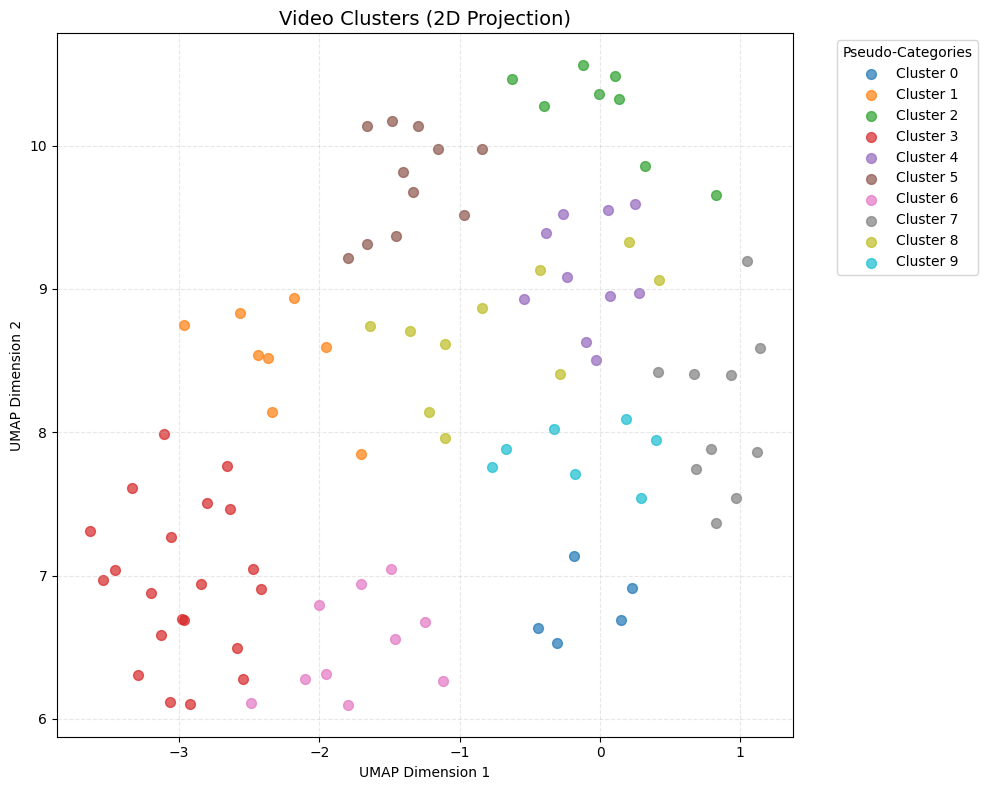

Pseudo scores length: 3000


In [4]:
pseudo_scores_flat = get_pseudo_highlight_scores(
    audio_embeddings_list=audio_embeddings_list,
    video_embeddings_list=video_embeddings_list,
)

print("Pseudo scores length:", len(pseudo_scores_flat))

In [36]:
def split_scores_by_embeddings(scores_flat, embeddings_list):
    """
    scores_flat: list or 1D array of length == total number of segments used in PHS
    embeddings_list: list of (T_i, D) arrays
    -> list of (T_i,) arrays, one per video
    """
    out = []
    idx = 0
    for emb in embeddings_list:
        L = emb.shape[0]  # number of segments for this video
        out.append(np.array(scores_flat[idx:idx + L], dtype=np.float32))
        idx += L
    assert idx == len(scores_flat), f"Used {idx} scores, but have {len(scores_flat)}"
    return out


In [37]:
pseudo_scores_per_video = split_scores_by_embeddings(
    pseudo_scores_flat,
    video_embeddings_list,  # or audio_embeddings_list, same segment lengths
)

for i, arr in enumerate(pseudo_scores_per_video):
    print(f"Video {i}: pseudo-score shape {arr.shape}")

Video 0: pseudo-score shape (30,)
Video 1: pseudo-score shape (30,)
Video 2: pseudo-score shape (30,)
Video 3: pseudo-score shape (30,)
Video 4: pseudo-score shape (30,)
Video 5: pseudo-score shape (30,)
Video 6: pseudo-score shape (30,)
Video 7: pseudo-score shape (30,)
Video 8: pseudo-score shape (30,)
Video 9: pseudo-score shape (30,)
Video 10: pseudo-score shape (30,)
Video 11: pseudo-score shape (30,)
Video 12: pseudo-score shape (30,)
Video 13: pseudo-score shape (30,)
Video 14: pseudo-score shape (30,)
Video 15: pseudo-score shape (30,)
Video 16: pseudo-score shape (30,)
Video 17: pseudo-score shape (30,)
Video 18: pseudo-score shape (30,)
Video 19: pseudo-score shape (30,)
Video 20: pseudo-score shape (30,)
Video 21: pseudo-score shape (30,)
Video 22: pseudo-score shape (30,)
Video 23: pseudo-score shape (30,)
Video 24: pseudo-score shape (30,)
Video 25: pseudo-score shape (30,)
Video 26: pseudo-score shape (30,)
Video 27: pseudo-score shape (30,)
Video 28: pseudo-score shape (

### Converting pseudo-scores to pseudo-labels

In [58]:
pseudo_labels_per_video = []
for scores in pseudo_scores_per_video:  # scores: (T_i,)
    thr = np.quantile(scores, 1 - top_ratio)    # top X% as positives
    labels = (scores >= thr).astype(np.float32) # (T_i,)
    pseudo_labels_per_video.append(labels)

for i, y in enumerate(pseudo_labels_per_video):
    print(f"Video {i}: {y.sum()} positives out of {len(y)}")

Video 0: 15.0 positives out of 30
Video 1: 15.0 positives out of 30
Video 2: 15.0 positives out of 30
Video 3: 15.0 positives out of 30
Video 4: 15.0 positives out of 30
Video 5: 15.0 positives out of 30
Video 6: 15.0 positives out of 30
Video 7: 15.0 positives out of 30
Video 8: 15.0 positives out of 30
Video 9: 15.0 positives out of 30
Video 10: 15.0 positives out of 30
Video 11: 15.0 positives out of 30
Video 12: 15.0 positives out of 30
Video 13: 15.0 positives out of 30
Video 14: 15.0 positives out of 30
Video 15: 15.0 positives out of 30
Video 16: 15.0 positives out of 30
Video 17: 15.0 positives out of 30
Video 18: 15.0 positives out of 30
Video 19: 15.0 positives out of 30
Video 20: 15.0 positives out of 30
Video 21: 15.0 positives out of 30
Video 22: 15.0 positives out of 30
Video 23: 15.0 positives out of 30
Video 24: 15.0 positives out of 30
Video 25: 15.0 positives out of 30
Video 26: 15.0 positives out of 30
Video 27: 15.0 positives out of 30
Video 28: 15.0 positives out o

In [59]:
# ---- NEW: compute positive class weight for BCE from pseudo-labels ----
all_labels = np.concatenate(pseudo_labels_per_video)        # shape (total_T,)
pos_fraction = float(all_labels.mean())                     # fraction of positives in all clips

# avoid division by zero; if no positives, fall back to weight 1.0
if pos_fraction > 0.0:
    w_p = (1.0 - pos_fraction) / max(pos_fraction, 1e-6)
else:
    w_p = 1.0

print(f"Global positive fraction: {pos_fraction:.4f}, pos_weight={w_p:.2f}")
pos_weight = torch.tensor([w_p], device=device)
# ---------------------------------------------------------------------- 


Global positive fraction: 0.5000, pos_weight=1.00


### Padding utilities

In [60]:
def to_padded_batch(emb_list, device):
    """
    emb_list: list of (T_i, D) tensors or ndarrays
    returns:
        x:   (B, T_max, D)
        m:   (B, T_max) bool mask (True = valid)
        lens: list of original lengths
    """
    tensors = [torch.as_tensor(e, dtype=torch.float32, device=device) for e in emb_list]
    lens = [t.shape[0] for t in tensors]
    B = len(tensors)
    D = tensors[0].shape[1]
    T_max = max(lens)

    x = torch.zeros((B, T_max, D), dtype=torch.float32, device=device)
    m = torch.zeros((B, T_max), dtype=torch.bool, device=device)

    for i, t in enumerate(tensors):
        L = t.shape[0]
        x[i, :L] = t
        m[i, :L] = True

    return x, m, lens

def unpad_to_lists(x, lens):
    """
    x: (B, T_max, ...)
    lens: list of lengths
    returns list of (T_i, ...) tensors on CPU
    """
    out = []
    for i, L in enumerate(lens):
        out.append(x[i, :L].detach().cpu())
    return out


In [61]:
v_batch, v_mask, v_lens = to_padded_batch(video_embeddings_list, device)
a_batch, a_mask, a_lens = to_padded_batch(audio_embeddings_list, device)

# sanity: they SHOULD match because we segmented with same schedule
assert v_lens == a_lens, "Audio/video segment counts per clip must match"

B, T_max_v, D_v = v_batch.shape
_, T_max_a, D_a = a_batch.shape
assert T_max_v == T_max_a, "Max time for A/V should match"

### Building labels batch

In [62]:
y_batch = torch.zeros((B, T_max_v), dtype=torch.float32, device=device)
for i, L in enumerate(v_lens):
    y_batch[i, :L] = torch.from_numpy(pseudo_labels_per_video[i]).to(device)

### Building model components

In [63]:
# self-attention encoders per modality
video_self_att = SelfAttention(D_v, d_self).to(device)
audio_self_att = SelfAttention(D_a, d_self).to(device)

# projection into common AV space
proj_v = nn.Linear(D_v, D_common).to(device)
proj_a = nn.Linear(D_a, D_common).to(device)

# bimodal self-attention
bimodal_att = BimodalSelfAttention(D_common, d_bimodal).to(device)

# per-segment highlight classifier
head = HighlightClassifier(D=D_common, hidden=hidden, p=dropout).to(device)

# optimizer & loss
params = (
    list(video_self_att.parameters()) +
    list(audio_self_att.parameters()) +
    list(proj_v.parameters()) +
    list(proj_a.parameters()) +
    list(bimodal_att.parameters()) +
    list(head.parameters()) +
    [alpha_logits]  # <-- include learnable fusion weights
)

optimizer = optim.Adam(params, lr=lr)

# use class-weighted BCE to compensate for rare positive (highlight) clips
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1.0], device=device))


### Training loop

In [64]:
num_videos = len(video_embeddings_list)

for epoch in range(num_epochs):
    video_self_att.train()
    audio_self_att.train()
    proj_v.train()
    proj_a.train()
    bimodal_att.train()
    head.train()

    # shuffle video indices each epoch
    indices = np.random.permutation(num_videos)

    epoch_loss = 0.0
    n_batches = 0

    for start in range(0, num_videos, batch_size):
        batch_idxs = indices[start:start + batch_size]

        # ---- build per-batch lists ----
        v_list = [video_embeddings_list[i] for i in batch_idxs]
        a_list = [audio_embeddings_list[i] for i in batch_idxs]
        y_list = [pseudo_labels_per_video[i] for i in batch_idxs]

        # ---- pad audio/video ----
        v_batch, v_mask, v_lens = to_padded_batch(v_list, device)
        a_batch, a_mask, a_lens = to_padded_batch(a_list, device)

        # sanity: lens must match
        assert v_lens == a_lens

        B, T_max_v, D_v = v_batch.shape

        # ---- pad labels to same shape (B, T_max_v) ----
        y_batch = torch.zeros((B, T_max_v), dtype=torch.float32, device=device)
        for bi, L in enumerate(v_lens):
            y_batch[bi, :L] = torch.from_numpy(y_list[bi]).to(device)

        # ---- forward ----
        optimizer.zero_grad()

        # 1) self-attention per modality
        v_self = video_self_att(v_batch, mask=v_mask)  # (B, T, D_v)
        a_self = audio_self_att(a_batch, mask=a_mask)  # (B, T, D_a)

        # 2) project to common space
        v_common = proj_v(v_self)                      # (B, T, D_common)
        a_common = proj_a(a_self)                      # (B, T, D_common)

        # 3) bimodal cross-attention
        v2a, a2v = bimodal_att(
            v_self=v_common,
            a_self=a_common,
            mask_v=v_mask,
            mask_a=a_mask,
        )                                              # (B, T, D_common)

        # 4) fuse 4 streams
        alpha = F.softmax(alpha_logits, dim=0).view(4, 1, 1, 1)
        comps = torch.stack([v_common, v2a, a2v, a_common], dim=0)
        z = (alpha * comps).sum(dim=0)                 # (B, T, D_common)

        # 5) classifier
        logits = head(z)                               # (B, T)

        # 6) loss only on valid positions
        loss = criterion(logits[v_mask], y_batch[v_mask])

        # ---- backward ----
        loss.backward()
        # optional: gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(params, max_norm=5.0)
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    avg_loss = epoch_loss / max(n_batches, 1)
    print(f"Epoch {epoch+1}/{num_epochs} - avg batch loss: {avg_loss:.4f}")


Epoch 1/100 - avg batch loss: 0.7372
Epoch 2/100 - avg batch loss: 0.6807
Epoch 3/100 - avg batch loss: 0.6475
Epoch 4/100 - avg batch loss: 0.6159
Epoch 5/100 - avg batch loss: 0.5860
Epoch 6/100 - avg batch loss: 0.5471
Epoch 7/100 - avg batch loss: 0.5399
Epoch 8/100 - avg batch loss: 0.5093
Epoch 9/100 - avg batch loss: 0.4996
Epoch 10/100 - avg batch loss: 0.4783
Epoch 11/100 - avg batch loss: 0.4439
Epoch 12/100 - avg batch loss: 0.4248
Epoch 13/100 - avg batch loss: 0.4193
Epoch 14/100 - avg batch loss: 0.3944
Epoch 15/100 - avg batch loss: 0.3757
Epoch 16/100 - avg batch loss: 0.3549
Epoch 17/100 - avg batch loss: 0.3492
Epoch 18/100 - avg batch loss: 0.3322
Epoch 19/100 - avg batch loss: 0.3298
Epoch 20/100 - avg batch loss: 0.3159
Epoch 21/100 - avg batch loss: 0.2998
Epoch 22/100 - avg batch loss: 0.2866
Epoch 23/100 - avg batch loss: 0.2693
Epoch 24/100 - avg batch loss: 0.2662
Epoch 25/100 - avg batch loss: 0.2530
Epoch 26/100 - avg batch loss: 0.2304
Epoch 27/100 - avg ba

### Serving trained model

In [45]:
torch.save(
    {
        "video_self_att": video_self_att.state_dict(),
        "audio_self_att": audio_self_att.state_dict(),
        "proj_v": proj_v.state_dict(),
        "proj_a": proj_a.state_dict(),
        "bimodal_att": bimodal_att.state_dict(),
        "head": head.state_dict(),
    },
    "av_highlight_model.pt",
)
print("Model saved to av_highlight_model.pt")


Model saved to av_highlight_model.pt


### Inference on the same batch & convert back to lists

In [ ]:
video_self_att.eval()
audio_self_att.eval()
proj_v.eval()
proj_a.eval()
bimodal_att.eval()
head.eval()

with torch.no_grad():
    # re-run forward for inference (could also cache z after training)
    v_self = video_self_att(v_batch, mask=v_mask)
    a_self = audio_self_att(a_batch, mask=a_mask)

    v_common = proj_v(v_self)
    a_common = proj_a(a_self)

    v2a, a2v = bimodal_att(
        v_self=v_common,
        a_self=a_common,
        mask_v=v_mask,
        mask_a=a_mask,
    )

    comps = torch.stack([v_common, v2a, a2v, a_common], dim=0)
    z = (alpha * comps).sum(dim=0)

    logits = head(z)                       # (B, T)
    probs = torch.sigmoid(logits)          # (B, T)
    probs_bt = probs.masked_fill(~a_mask, 0.0)  # padded positions zeroed

# convert back to per-clip lists
highlight_probs = unpad_to_lists(probs_bt.unsqueeze(-1), a_lens)
# now highlight_probs[i] has shape (T_i, 1) with per-segment scores

# print results
for i, (vp, ap, scores) in enumerate(zip(video_paths, audio_paths, highlight_probs)):
    if i == 92:
        print(f"\nClip {i}:")
        print(f"  video: {vp}")
        print(f"  audio: {ap}")
        print(f"  highlight probs (T={scores.shape[0]}):")
        print(scores.squeeze(-1).numpy())


Clip 0:
  video: data/videos\video_part_000.mp4
  audio: data/audios\time1_part1.mp3
  highlight probs (T=30):
[9.9938083e-01 5.4315012e-04 1.8174150e-04 1.8316999e-04 9.9952447e-01
 2.0829419e-04 8.5826486e-04 9.9959606e-01 9.9969411e-01 9.9976462e-01
 3.6243041e-04 9.9974459e-01 2.1229908e-04 1.7240150e-04 2.3033886e-04
 9.9949515e-01 9.9975055e-01 9.9960262e-01 9.9973327e-01 9.9964988e-01
 9.9973339e-01 9.9976224e-01 2.4632513e-04 2.1578230e-04 1.9442401e-04
 2.3463237e-04 1.8457940e-04 9.9972624e-01 9.9976712e-01 1.7739972e-04]

Clip 1:
  video: data/videos\video_part_001.mp4
  audio: data/audios\time1_part10.mp3
  highlight probs (T=30):
[9.9977225e-01 9.9976462e-01 9.9973410e-01 9.9974889e-01 9.9975818e-01
 9.9976808e-01 9.9978298e-01 9.9977285e-01 4.9916166e-04 9.9905580e-01
 2.0179036e-04 9.9922907e-01 9.7742910e-04 9.9977738e-01 9.9977261e-01
 9.9968660e-01 9.9978703e-01 2.2913936e-04 9.9919957e-01 1.6010626e-03
 1.9725479e-04 2.0874431e-04 3.5795924e-04 1.9393410e-04 1.96039

In [75]:
for i, (vp, ap, scores) in enumerate(zip(video_paths, audio_paths, highlight_probs)):
    print(i)
    if i == 92:
        print(f"\nClip {i}:")
        print(f"  video: {vp}")
        print(f"  audio: {ap}")
        print(f"  highlight probs (T={scores.shape[0]}):")
        print(scores.squeeze(-1).numpy())

0
1
2
3


In [73]:
len(highlight_probs)

4

In [66]:
import numpy as np

# how aggressively to cut
highlight_top_ratio = 0.2  # keep top 50% segments as highlights
min_clip_duration = 1     # seconds; discard too-short tiny clip

In [67]:
def mask_to_time_ranges(mask, seg_duration, min_clip_duration=0.0):
    """
    mask: 1D boolean array, length T (True = highlight segment)
    seg_duration: float, seconds per segment
    returns list of (start_time, end_time) in seconds
    """
    ranges = []
    start_idx = None
    T = len(mask)

    for i, is_on in enumerate(mask):
        if is_on and start_idx is None:
            start_idx = i
        elif not is_on and start_idx is not None:
            end_idx = i  # end is non-inclusive
            start_t = start_idx * seg_duration
            end_t = end_idx * seg_duration
            if end_t - start_t >= min_clip_duration:
                ranges.append((start_t, end_t))
            start_idx = None

    # tail segment
    if start_idx is not None:
        start_t = start_idx * seg_duration
        end_t = T * seg_duration
        if end_t - start_t >= min_clip_duration:
            ranges.append((start_t, end_t))

    return ranges


In [24]:
!pip install moviepy


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import moviepy

In [70]:
from moviepy import VideoFileClip, concatenate_videoclips  # note: .editor

CLIP_DURATION = 29.0  # seconds, fixed for all your clips
PRE_ROLL = 10.0       # seconds before highlight to include

all_highlight_clips = []   # all clips from all videos (for a single big reel)
base_clips = []            # keep references so they don't get garbage-collected

for i, (vpath, scores_tensor) in enumerate(zip(video_paths, highlight_probs)):
    # scores_tensor: shape (T_i, 1) on CPU
    scores = scores_tensor.squeeze(-1).numpy()      # (T_i,)
    T_i = len(scores)

    # segment duration from known clip length and #segments
    seg_dur = CLIP_DURATION / T_i

    # pick top X% segments per video as highlight
    thr = np.quantile(scores, 1.0 - highlight_top_ratio)
    mask = scores >= thr                           # boolean mask (T_i,)

    time_ranges = mask_to_time_ranges(
        mask,
        seg_duration=seg_dur,
        min_clip_duration=min_clip_duration
    )

    print(f"\nVideo {i} ({vpath}):")
    print(f"  T_i (segments): {T_i}")
    print(f"  segment duration: {seg_dur:.3f} s")
    print(f"  picked {mask.sum()} segments as highlights")
    print(f"  time ranges (original): {time_ranges}")

    if not time_ranges:
        continue

    # load original video and cut highlights
    base_clip = VideoFileClip(vpath)
    base_clips.append(base_clip)   # <- keep reference, DON'T close yet

    per_video_clips = []
    for (start_t, end_t) in time_ranges:
        # extend 10s before highlight start
        pre_start = max(0.0, start_t - PRE_ROLL)

        # guard for slight rounding issues
        pre_start = max(0.0, pre_start)
        end_t = min(base_clip.duration, end_t)

        if end_t - pre_start < min_clip_duration:
            continue

        sub = base_clip.subclipped(pre_start, end_t)  # <- fixed name + pre-roll
        per_video_clips.append(sub)
        all_highlight_clips.append(sub)

    # OPTIONAL: save per-video highlight file too
    if per_video_clips:
        per_video_highlight = concatenate_videoclips(per_video_clips)
        out_path = os.path.splitext(vpath)[0] + "_highlights.mp4"
        per_video_highlight.write_videofile(
            out_path,
            codec="libx264",
            audio_codec="aac"
        )
        per_video_highlight.close()

# GLOBAL highlight reel from all videos
if all_highlight_clips:
    final_highlights = concatenate_videoclips(all_highlight_clips)
    final_highlights.write_videofile(
        "all_highlights.mp4",
        codec="libx264",
        audio_codec="aac"
    )
    final_highlights.close()
else:
    print("No highlight segments selected — check your threshold/top_ratio.")

# NOW it's safe to close all base clips
for bc in base_clips:
    bc.close()



Video 0 (data/videos\video_part_000.mp4):
  T_i (segments): 30
  segment duration: 0.967 s
  picked 7 segments as highlights
  time ranges (original): [(19.333333333333332, 21.266666666666666)]
MoviePy - Building video data/videos\video_part_000_highlights.mp4.
MoviePy - Writing audio in video_part_000_highlightsTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
MoviePy - Writing video data/videos\video_part_000_highlights.mp4



MoviePy - Done !
MoviePy - video ready data/videos\video_part_000_highlights.mp4

Video 1 (data/videos\video_part_001.mp4):
  T_i (segments): 30
  segment duration: 0.967 s
  picked 6 segments as highlights
  time ranges (original): [(5.8, 7.733333333333333), (12.566666666666666, 14.5)]
MoviePy - Building video data/videos\video_part_001_highlights.mp4.
MoviePy - Writing audio in video_part_001_highlightsTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
MoviePy - Writing video data/videos\video_part_001_highlights.mp4



MoviePy - Done !
MoviePy - video ready data/videos\video_part_001_highlights.mp4

Video 2 (data/videos\video_part_002.mp4):
  T_i (segments): 30
  segment duration: 0.967 s
  picked 6 segments as highlights
  time ranges (original): [(0.0, 3.8666666666666667)]
MoviePy - Building video data/videos\video_part_002_highlights.mp4.
MoviePy - Writing audio in video_part_002_highlightsTEMP_MPY_wvf_snd.mp4


...

MoviePy - Done !
MoviePy - video ready data/videos\video_part_002_highlights.mp4

Video 3 (data/videos\video_part_003.mp4):
  T_i (segments): 30
  segment duration: 0.967 s
  picked 6 segments as highlights
  time ranges (original): [(21.266666666666666, 23.2), (26.1, 28.033333333333335)]
MoviePy - Building video data/videos\video_part_003_highlights.mp4.
MoviePy - Writing audio in video_part_003_highlightsTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
MoviePy - Writing video data/videos\video_part_003_highlights.mp4



MoviePy - Done !
MoviePy - video ready data/videos\video_part_003_highlights.mp4
MoviePy - Building video all_highlights.mp4.
MoviePy - Writing audio in all_highlightsTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
MoviePy - Writing video all_highlights.mp4



MoviePy - Done !
MoviePy - video ready all_highlights.mp4
